## Seaborn: Visualización Estadística
**Curso:** Programación para Ciencia de Datos
**Docente:** Leondry Mayeta Revilla, PhD(c) · leondry.mayeta@upeu.edu.pe · Universidad Peruana Unión

**Unidad 3:** Visualización y Procesamiento de Información

Hoy seleccionas e interpretas visualizaciones estadísticas de
distribución, relación, comparación categórica y correlación.


In [ ]:
# Montar Google Drive — ejecutar primero
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Verificación de Insumos y Continuidad S08 → S09

Seaborn está construido sobre Matplotlib, pero pensado para estadística: se integra
de forma nativa con DataFrames (las columnas se pasan por nombre, no como arrays) y
el parámetro `hue` colorea por categoría sin bucles adicionales.


## Secuencia a desarrollar en actividad práctica

### Bloque I — Guiado con docente (dataset de referencia)
```
S1 Distribuciones   →  histograma / densidad / caja-bigotes / violín
S2 Relaciones       →  dispersión / tendencia / matriz de pares
S3 Categórica+corr  →  barras de media / frecuencias / mapa de calor
```
> Sección con ejercicio con dataset de referencia

### Bloque II — Autónomo por equipo (tu dataset)
```
Réplica S1          →  distribuciones sobre tu variable numérica principal
Réplica S2          →  relaciones entre tus variables
Réplica S3          →  comparación categórica + heatmap de correlación
Taller              →  G7–G10 (libres, uno por pregunta analítica)
                        + G11 mapa de calor (obligatorio)
                                    ↓
                     Síntesis: 5 hallazgos acumulados S08 + S09
                                    ↓
                         Insumo 2 del Dashboard U3
```


---
## Sección 1 — Distribuciones: histplot, kdeplot, boxplot, violinplot

Cuatro formas de ver cómo se distribuyen los valores de una variable:

```
histplot   →  barras de frecuencia, con curva de densidad opcional (kde=True)
kdeplot    →  solo la curva, ideal para comparar varios grupos con hue
boxplot    →  caja + outliers, mejor para detectar valores extremos
violinplot →  forma completa de la distribución, por categoría
```

La elección depende de la pregunta: ¿forma general, comparación entre grupos, o detección de outliers?

---
## Bloque II — Tu dataset · trabajo autónomo


In [ ]:
# ── FLUJO ─────────────────────────────────────────────────────────────────────────
# 1. ¿Cómo están separados los valores en tu archivo?
#    Abre el CSV en un editor de texto y observa el primer separador:
#    ¿coma entre columnas?  → carga estándar
#    ¿tabulación (TAB)?     → indica el separador al cargar  ← D03: marketing_campaign
#    Esta separados por comas
# 2. Ejecuta y verifica: ¿cuántas columnas aparecen?
#    Si aparece 1 sola columna → separador incorrecto, ajusta y re-ejecuta
#    Aparece 20 columnas
# 3. ¿Quedan valores nulos? → los mismos de S07/S08, o justifica si aparecen nuevos
#    No quedan valores nulos
# ── FIN FLUJO ─────────────────────────────────────────────────────────────────────────
# EQUIPO: cargar el mismo CSV procesado que usaron en S08
RUTA_CSV_EQUIPO = '/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DEL CURSO/anonymisedData/df_limpio_procesado.pkl'

# NOTA: si tu archivo usa separador TAB (ej. marketing_campaign.csv de Kaggle):
# df = pd.read_csv(RUTA_CSV_EQUIPO, sep='\t')
# df = pd.read_csv(RUTA_CSV_EQUIPO)
df = pd.read_pickle(RUTA_CSV_EQUIPO )

print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])
print('Nulos residuales:', df.isnull().sum().sum())
df.head(3)

Filas: 32593
Columnas: 20
Nulos residuales: 0


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_assessments_submitted,average_score,total_weighted_score,total_clicks,unique_days_active
0,aaa,2013j,11391,m,east anglian region,he qualification,90-100%,mayor o igual a 55 años,0,240,n,pass,-159,268,268,5,82.0,82.4,934,40
1,aaa,2013j,28400,f,scotland,he qualification,20-30%,entre 35 y 55 años,0,60,n,pass,-53,268,268,5,66.4,65.4,1435,80
2,aaa,2013j,30268,f,north western region,a level or equivalent,30-40%,entre 35 y 55 años,0,60,y,withdrawn,-92,12,268,0,0.0,0.0,281,12


In [ ]:
df.describe()

,id_student,num_of_prev_attempts,studied_credits,date_registration,date_unregistration,module_presentation_length,total_assessments_submitted,average_score,total_weighted_score,total_clicks,unique_days_active
count,3.259300e+04,32593.000000,32593.000000,32593.00000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691,-69.76004,191.651858,256.010125,5.335870,57.646621,48.494655,1215.141257,55.475685
std,5.491673e+05,0.479758,41.071900,50.11205,106.650046,13.179078,4.326009,32.926518,49.288286,1692.604449,54.515290
min,3.733000e+03,0.000000,30.000000,-322.00000,-365.000000,234.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.085730e+05,0.000000,60.000000,-101.00000,130.000000,241.000000,1.000000,43.000000,0.000000,142.000000,11.000000
50%,5.903100e+05,0.000000,60.000000,-57.00000,241.000000,262.000000,5.000000,70.571429,40.700000,602.000000,40.000000
75%,6.444530e+05,0.000000,120.000000,-29.00000,268.000000,268.000000,9.000000,82.400000,80.750000,1585.000000,85.000000
max,2.716795e+06,6.000000,655.000000,167.00000,444.000000,269.000000,14.000000,100.000000,200.000000,24139.000000,286.000000


Segun el dataset del grupo, tenemos las sigueinte variables numericas mas significativas

- average_score (valores entre 0 y 100)

- total_clicks (valores entre 0 y 24139)

- total_weighted_score (valores entre 0 y 200)

-  total_assessments_submitted (valores entre 0 y 14)

- num_of_prev_attempts (valores entre 0 y 6)

- studied_credits (valores entre 30  y 655)

- total_clicks (valores entre 0 y 24139)

- unique_days_active (valores entre 0 y 286)

Debido a que  las escalas son diferentes (por ejemplo, total_clicks llega hasta 24,139 y num_of_prev_attempts solo llega a 6), no podemos usar la desviación estándar normal. Si usamos la desviación estándar normal, total_clicks siempre ganará por pura escala física, lo cual sería un error en tu análisis. Para poder comparar la variabilidad real de forma justa, debemos usar el Coeficiente de Variación (CV), que divide la desviación estándar entre la media

In [ ]:
import pandas as pd

columnas = [
    'average_score',
    'total_clicks',
    'total_weighted_score',
    'total_assessments_submitted',
    'num_of_prev_attempts',
    'studied_credits',
    'unique_days_active'
]

cv = {}

for col in columnas:
    cv[col] = (df[col].std() / df[col].mean()) * 100

# Mostrar las 3 variables con mayor variabilidad
top3 = pd.Series(cv).sort_values(ascending=False).head(3)

print(top3)

num_of_prev_attempts    293.924210
total_clicks            139.292814
total_weighted_score    101.636533
dtype: float64


In [ ]:
# Las variables total clics, intentos previos y puntaje promedio total son las que capturan el comportamiento real, caótico y variado de los alumnos
# Las variables de alta variabilidad suelen ser excelentes predictoras porque dividen muy bien a la población.
# Alta variabilidad significa que los datos son caóticos, dispersos o agrupados en extremos, por ejemplo formando un grupo en rangos de 0 a 10, y otro grupo de 90 a 100
# Mayor variabilidad significa mayor heterogeneidad en los datos, hay picos y bajas, o concetracion de datos en puntos especificos distantes

In [ ]:
df['final_result'].unique()

['pass', 'withdrawn', 'fail', 'distinction']
Categories (4, object): ['distinction', 'fail', 'pass', 'withdrawn']

COLUMNAS CATEGORICAS RELEVANTES

- gender  con valores F y M
- region con valores 'east anglian region', 'scotland', 'north western region', 'south east region', 'west midlands region', ..., 'ireland', 'south west region', 'east midlands region', 'yorkshire region', 'london region'
- highest_education con valores 'he qualification', 'a level or equivalent', 'lower than a level', 'post graduate qualification', 'no formal quals'
- imd_band con valores de '90-100%', '20-30%', '30-40%', '50-60%', '80-90%', '70-80%', '60-70%', '40-50%', '10-20%', '0-10%'
- age_band con valores 'mayor o igual a 55 años', 'entre 35 y 55 años', 'menor o igual a 35 años'
- disability con valores 'n', 'y'
- final_result con valores 'pass', 'withdrawn', 'fail', 'distinction'


In [ ]:
# Busqueda de variables categoricas que tiene mas relevancia hacia el objetivo es final_result
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# Variables categóricas (sin incluir la variable objetivo)
variables = [
    'gender',
    'region',
    'highest_education',
    'imd_band',
    'age_band',
    'disability'
]

resultado = {}

for var in variables:
    # Tabla de contingencia
    tabla = pd.crosstab(df[var], df['final_result'])

    # Prueba Chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(tabla)

    # V de Cramér
    n = tabla.values.sum()
    r, k = tabla.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

    resultado[var] = cramers_v

# Mostrar las 2 variables más relevantes
top2 = pd.Series(resultado).sort_values(ascending=False).head(2)

print(top2)

highest_education    0.102370
imd_band             0.078815
dtype: float64


**[EQUIPO — completar]**
- Las 3 variables numéricas de mayor variabilidad: num_of_prev_attempts, total_clicks y total_weighted_score
- Las 2 variables categóricas más relevantes para la decisión:   highest_education y age_band
- Las 3 preguntas analíticas formuladas en el ANTES:
1. ¿Qué patrones se observan entre el resultado final (final_result) y las variables numéricas asociadas al desempeño académico y la interacción del estudiante?
2. ¿Qué patrones se observan en la distribución del resultado final (final_result) según las características demográficas y académicas categóricas de los estudiantes?
3. ¿Qué características demográficas, académicas y de interacción permiten caracterizar el perfil de los estudiantes según su resultado final (final_result)?



---
## Sección 4 — Taller: Ampliación del Dashboard U3

Construye sobre tu dataset las visualizaciones Seaborn que responden tus 3 preguntas analíticas del ANTES. Cada gráfico necesita:
- **Título con el hallazgo** (no solo el tema)
- **Etiquetas de ejes completas**
- **Celda markdown de interpretación** contextualizada al problema del equipo

Mínimo **4 gráficos nuevos** + el **heatmap de correlación** (obligatorio, con interpretación).

**Estructura del Dashboard U3:**
- S08: Gráficos 1–6 (Matplotlib)
- S09 (hoy): Gráficos 7–9 (Seaborn, responden tus 3 preguntas analíticas) + Gráfico 10 (libre) + Gráfico 11 heatmap (obligatorio)
- S10: EDA sistemático + narrativa + panel integrado final
---
**Antes de comenzar el taller, define por escrito:**

| # | Pregunta analítica | Variable(s) involucradas | Gráfico que usarás |
|---|---|---|---|
| G7 |¿Qué patrones se observan entre el resultado final (final_result) y las variables numéricas asociadas al desempeño académico y la interacción del estudiante? |    'average_score','total_weighted_score','total_clicks' 'unique_days_active', 'total_assessments_submitted' |Boxplot |
| G8 | ¿Qué patrones se observan en la distribución del resultado final (final_result) según las características demográficas y académicas categóricas de los estudiantes?|    'highest_education','age_band','gender','region','imd_band','disability' |countplot |
| G9 |¿Qué características demográficas, académicas y de interacción permiten caracterizar el perfil de los estudiantes según su resultado final (final_result)? |    'average_score','total_weighted_score','total_clicks','unique_days_active','total_assessments_submitted' |lineplot e histplot|
| G10 |¿Cómo se distribuyen las categorías de la variable objetivo (final_result) y existe evidencia de desbalance entre sus clases? |final_result | countplot|
| G11 | correlación entre variables numéricas | todas las numéricas | mapa de calor |

> La pregunta guía el gráfico — no al revés.


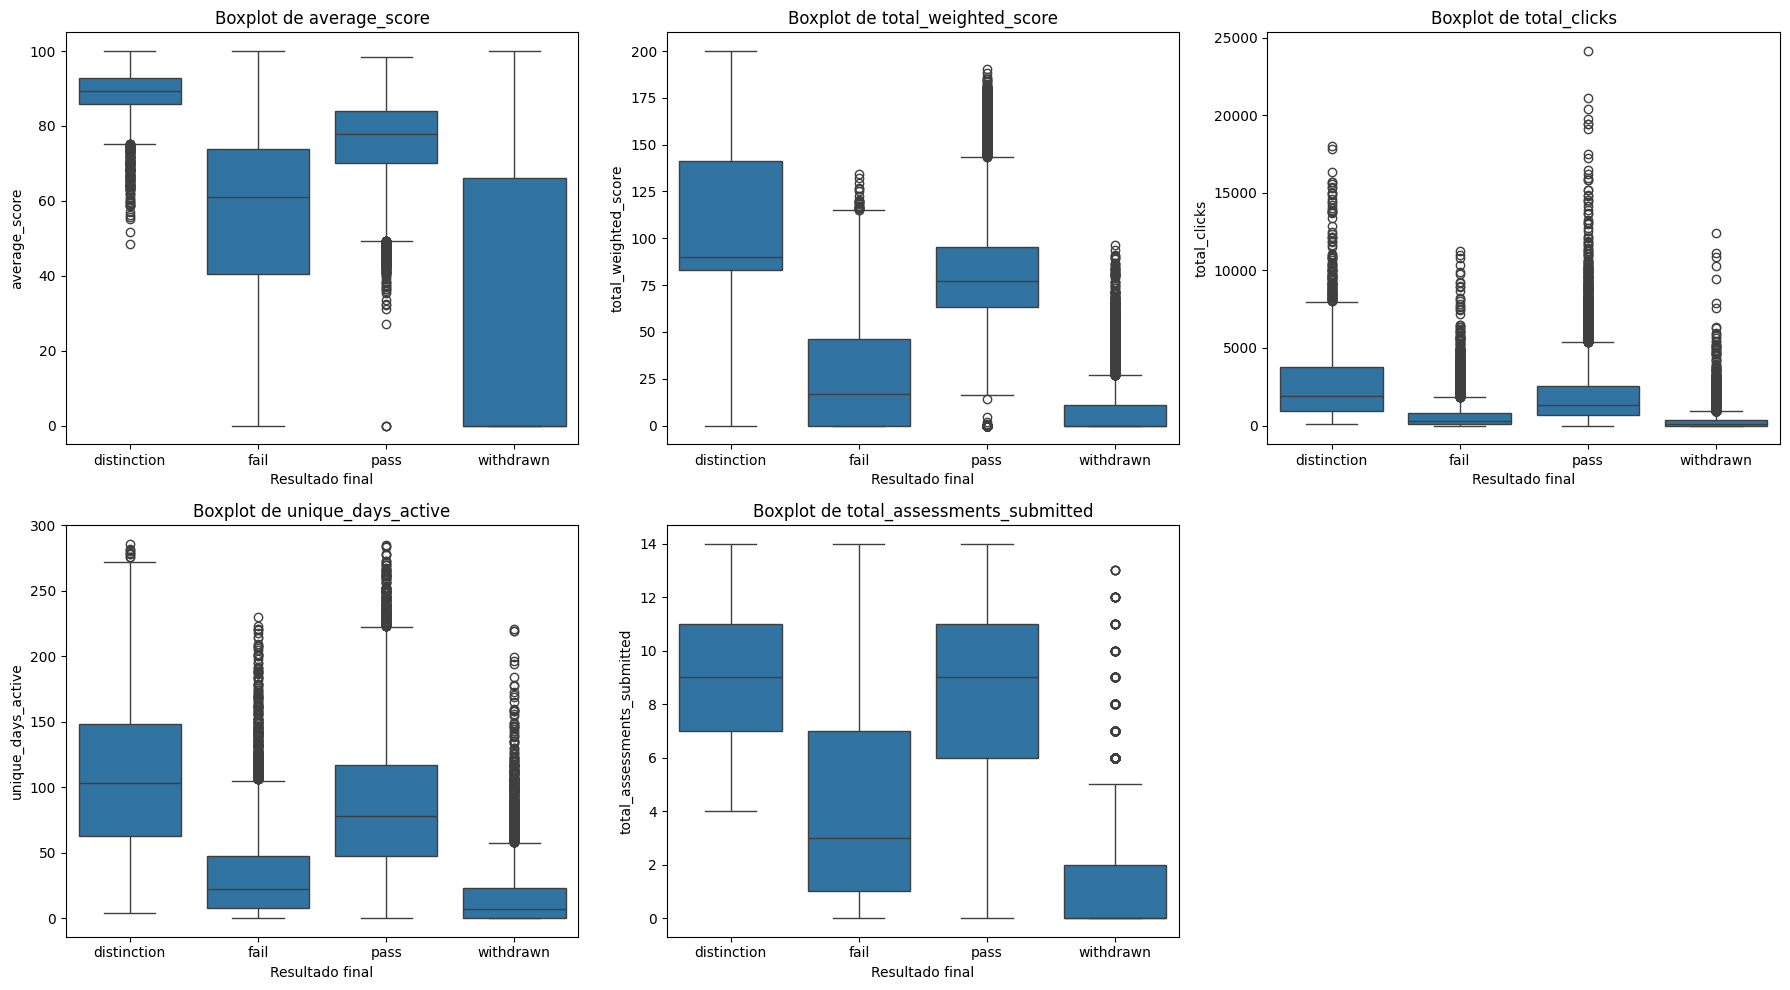

In [ ]:
# GRÁFICO 7 — Distribución sobre tu variable numérica principal
# Pregunta analítica 1: 1. ¿Qué patrones se observan entre el resultado final (final_result) y las variables numéricas asociadas al desempeño académico y la interacción del estudiante?
# Variable numérica principal: average_score
# Variable categórica para comparar: final_result

# ── FLUJO ─────────────────────────────────────────────────────────────────────────
# Decide ANTES de codificar — ¿qué quiero mostrar?
#   La forma general de cómo se distribuye una variable
#              → histograma (con curva de densidad si la distribución es continua)
#   Cómo varía esa distribución entre grupos + valores extremos
#              → diagrama de caja (elige la variable categórica para comparar)
#   Ambas vistas a la vez → dos paneles lado a lado
# Verifica: el título describe el hallazgo, no el nombre de la variable
# ── FIN FLUJO ─────────────────────────────────────────────────────────────────────────
# NOTA:
# No incluiría: studied_credits (es una característica inicial del estudiante, no refleja desempeño ni interacción).
# num_of_prev_attempts (es un antecedente académico, no una medida de desempeño durante el curso).
import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas a comparar con la variable objetivo que es final_result
variables = [
    'average_score',
    'total_weighted_score',
    'total_clicks',
    'unique_days_active',
    'total_assessments_submitted'
]

# Crear la grilla (2 filas x 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Convertir la matriz de ejes en un vector
axes = axes.flatten()

# Generar un boxplot para cada variable
for i, variable in enumerate(variables):
    sns.boxplot(data=df, x='final_result', y=variable, ax=axes[i])
    axes[i].set_title(f'Boxplot de {variable}')
    axes[i].set_xlabel('Resultado final')
    axes[i].set_ylabel(variable)

# Eliminar el último subplot vacío
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Hallazgo Gráfico 7 — Distribución:** _Tu interpretación aquí (1–2 oraciones)_

1. Variable: average_score. Los estudiantes con resultado Distinction presentan los valores más altos de average_score, con una mediana cercana a 90 puntos, mientras que los grupos Fail y Withdrawn muestran valores considerablemente menores. Además, existe una clara separación entre las cajas de las categorías, con poca superposición entre sus distribuciones. Esto evidencia que average_score presenta una fuerte relación con final_result, siendo una variable que permite diferenciar claramente entre estudiantes con alto y bajo desempeño académico.

2. Variable: total_weighted_score. La variable total_weighted_score muestra una tendencia similar a average_score, donde los estudiantes con categoría Distinction alcanzan los valores más elevados, seguidos por Pass, mientras que Fail y Withdrawn presentan menores puntuaciones. Aunque existen valores atípicos en varias categorías, la diferencia entre las medianas y la ubicación de las cajas evidencia una separación importante entre los resultados finales. Por ello, total_weighted_score presenta una alta relación con final_result y representa una variable relevante del desempeño académico.

3. Variable: total_clicks. La distribución de total_clicks muestra que los estudiantes con mejores resultados tienden a presentar una mayor interacción con la plataforma virtual. La categoría Distinction presenta una mediana superior a Fail y Withdrawn, mientras que Pass también muestra niveles elevados de actividad. Sin embargo, existe una amplia dispersión y presencia de numerosos valores atípicos en todas las categorías, lo que indica que la cantidad de interacciones puede variar considerablemente entre estudiantes. En consecuencia, total_clicks presenta una relación moderada con final_result, aunque con mayor variabilidad que las variables asociadas directamente al rendimiento académico.

4. Variable: unique_days_active. La variable unique_days_active evidencia diferencias entre las categorías de resultado final, observándose que los estudiantes con Distinction presentan mayor permanencia activa en la plataforma, mientras que los estudiantes con Withdrawn muestran los valores más bajos. La categoría Pass presenta valores intermedios y una distribución más cercana a Distinction que a Fail. Estos resultados sugieren que la permanencia y continuidad de la actividad en la plataforma virtual está relacionada con el resultado final del estudiante.

5. Variable: total_assessments_submitted. La cantidad de evaluaciones entregadas presenta una diferenciación entre las categorías de final_result. Los estudiantes con Distinction y Pass muestran medianas más altas, mientras que los estudiantes con Withdrawn presentan los valores más bajos. Aunque existe cierta superposición entre algunas categorías, principalmente entre Distinction y Pass, se observa una tendencia donde una mayor participación en actividades evaluativas está asociada con mejores resultados finales. Por ello, total_assessments_submitted presenta una relación positiva con final_result, aunque menor que las variables relacionadas con las calificaciones.

TODO: Interpretación general para responder la pregunta de investigación

En conjunto, los boxplots muestran que las variables con mayor relación visual con el resultado final (final_result) son average_score y total_weighted_score, debido a que presentan la mayor separación entre las categorías y una clara diferencia en sus valores centrales. Entre las variables relacionadas con la interacción en la plataforma virtual, unique_days_active y total_clicks muestran una asociación positiva, indicando que una mayor actividad del estudiante se relaciona con mejores resultados académicos. Finalmente, total_assessments_submitted también presenta una relación con el resultado final, aunque con menor capacidad de diferenciación entre categorías.

Por lo tanto, desde el análisis descriptivo mediante boxplots, las variables que muestran mayor potencial para explicar o predecir final_result son principalmente las variables de desempeño académico (average_score y total_weighted_score), seguidas por las variables de comportamiento en la plataforma virtual (unique_days_active, total_clicks y total_assessments_submitted).

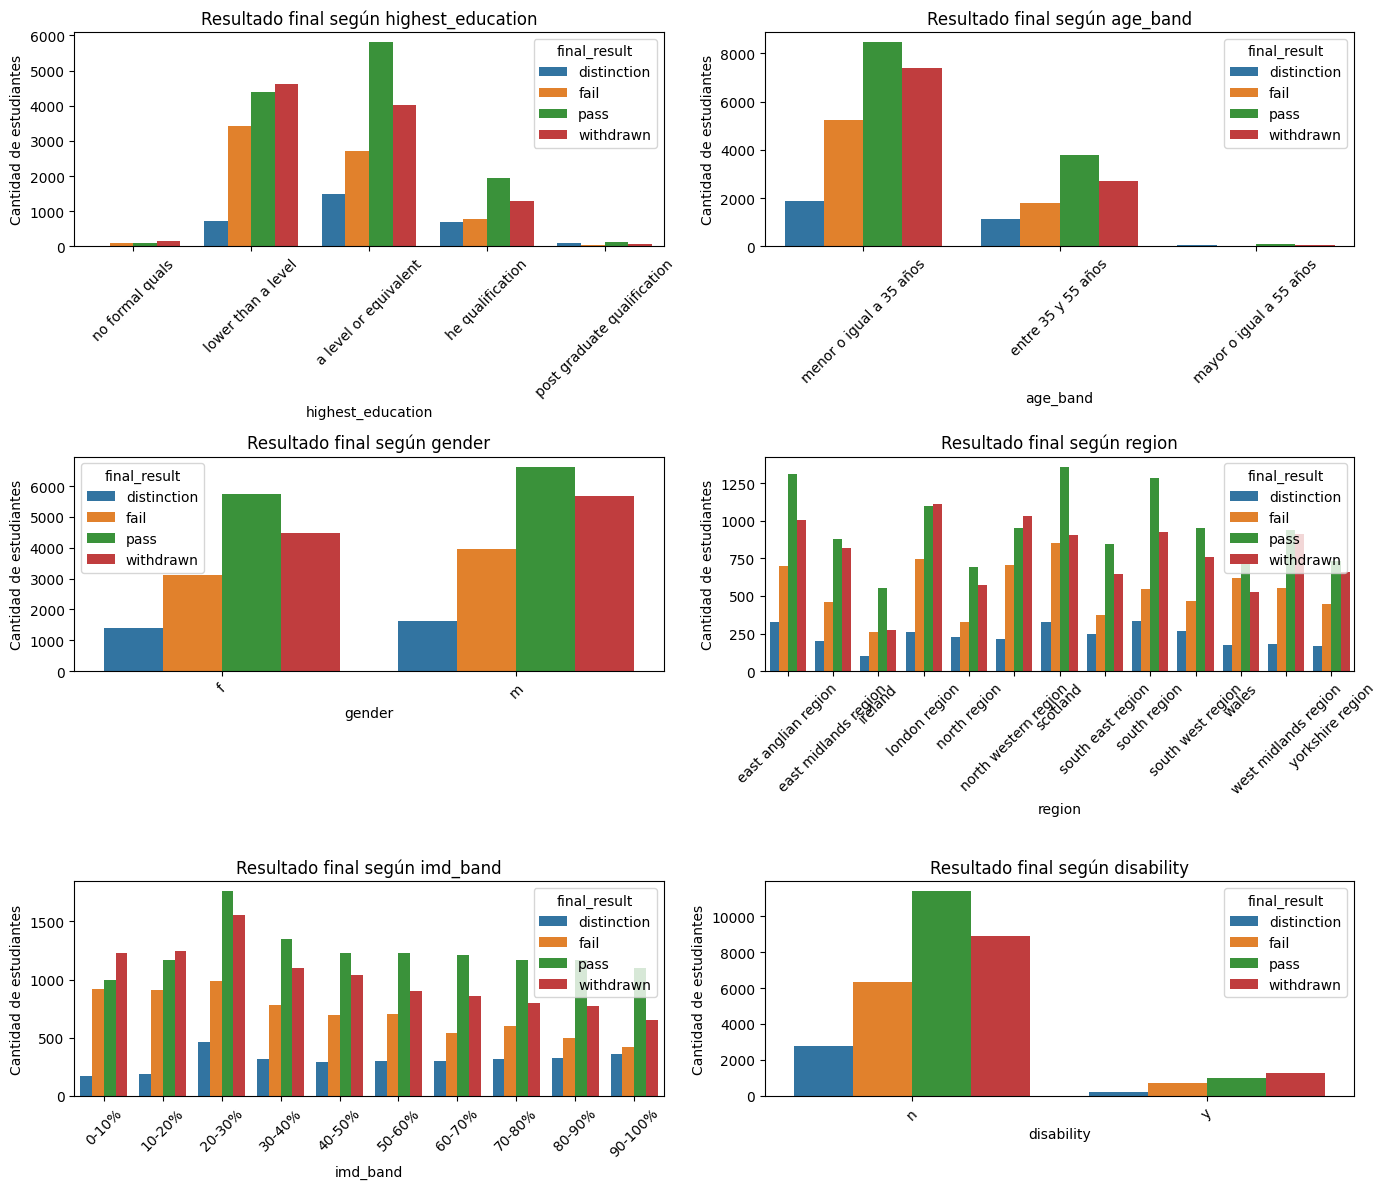

In [ ]:
# GRÁFICO 8 — Relaciones entre variables numéricas
# Pregunta analítica 2: ¿Qué patrones se observan en la distribución del resultado final (final_result) según las características demográficas y académicas categóricas de los estudiantes?
# Dos variables numéricas más relevantes: [indicar columnas]
# Variable categórica principal: [indicar columna]

# D03 marketing_campaign.csv — ejemplo:
# sns.scatterplot(df, x='Income', y='gasto_total', hue='Response', size='total_compras', alpha=0.5)
# sns.pairplot(df[['Income', 'gasto_total', 'total_compras']], hue='Response')

# ── FLUJO ─────────────────────────────────────────────────────────────────────────
# Decide ANTES de codificar — ¿cuántas variables quiero cruzar?
#   2 numéricas + 1 categórica como color
#              → gráfico de dispersión con grupos de color
#   2 numéricas + necesito ver la tendencia lineal
#              → dispersión con línea de tendencia (solo 2 variables, sin color)
#   3 o 4 numéricas + 1 categórica → matriz de pares
#              → máximo 4 columnas; más columnas hace el gráfico ilegible
# Verifica: ¿el gráfico responde UNA pregunta analítica concreta del ANTES?
# ── FIN FLUJO ─────────────────────────────────────────────────────────────────────────
# TU CÓDIGO AQUÍ
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Convertimos la matriz de ejes en una lista para acceder fácilmente
axes = axes.flatten()

variables_categoricas = [
    'highest_education',
    'age_band',
    'gender',
    'region',
    'imd_band',
    'disability'
]

for i, variable in enumerate(variables_categoricas):

    sns.countplot(
        data=df,
        x=variable,
        hue='final_result',
        ax=axes[i]
    )

    axes[i].set_title(f'Resultado final según {variable}')
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel('Cantidad de estudiantes')

    # Rotar etiquetas si son largas
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Hallazgo Gráfico 8 — Relaciones:**

El análisis de la distribución del resultado final (final_result) según las variables categóricas permite identificar patrones en el comportamiento académico de los estudiantes. En el caso de highest_education, se observa que los estudiantes con nivel educativo A Level or Equivalent concentran la mayor cantidad de estudiantes aprobados (pass), seguidos por aquellos con nivel Lower Than A Level, mientras que los niveles educativos superiores presentan menor cantidad debido a su menor representación en el conjunto de datos. Para age_band, se identifica que los estudiantes menores o iguales a 35 años representan el grupo más numeroso y concentran la mayor cantidad de aprobados, desaprobados y retiros, mientras que los grupos de mayor edad tienen una menor participación. En relación con gender, la distribución de resultados entre hombres y mujeres presenta un comportamiento similar, predominando en ambos casos los estudiantes con resultado pass, seguido de withdrawn y fail, sin diferencias visuales marcadas. Respecto a region, aunque existen variaciones en la cantidad de estudiantes entre las diferentes regiones, se mantiene un patrón general donde el resultado pass es el más frecuente en la mayoría de categorías. Para imd_band, los diferentes niveles socioeconómicos muestran distribuciones relativamente similares, predominando los estudiantes aprobados, aunque con presencia importante de estudiantes retirados y desaprobados en todos los grupos. Finalmente, en disability, se observa que la mayoría de estudiantes pertenece al grupo sin discapacidad, concentrando la mayor cantidad absoluta de resultados; el grupo con discapacidad presenta una menor cantidad de registros, pero mantiene una distribución semejante. En conjunto, los gráficos muestran que las variables con patrones visuales más diferenciados son el nivel educativo previo y la edad, mientras que género, región, nivel socioeconómico y discapacidad presentan distribuciones más homogéneas. Estos resultados exploratorios permiten identificar características categóricas que podrían ser consideradas posteriormente como variables de entrada para el modelo predictivo del resultado final.


/tmp/ipykernel_444/4161838306.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perfil = df.groupby('final_result')[variables].mean()


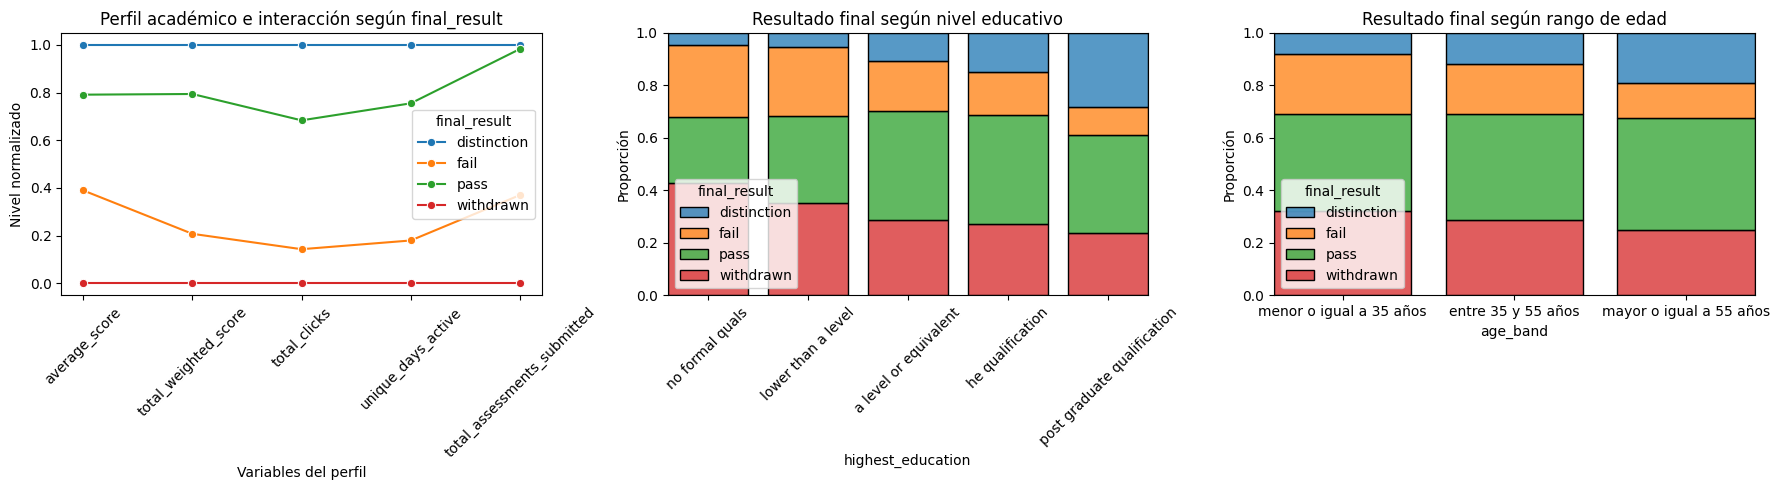

In [ ]:
# GRÁFICO 9 — Comparación entre categorías
# Pregunta analítica 3: ¿Qué características demográficas, académicas y de interacción permiten caracterizar el perfil de los estudiantes según su resultado final (final_result)?
# Variable categórica principal: [indicar columna]

# D03 marketing_campaign.csv — ejemplos:
# sns.barplot(df, x='Education', y='gasto_total', estimator='mean', errorbar='sd')
# sns.countplot(df, x='Marital_Status', order=df['Marital_Status'].value_counts().index)

# ── FLUJO ───────────────────────────────────────────────────────────────────────
# Decide ANTES de codificar — ¿qué quieres mostrar sobre tus categorías?
#   El promedio de una variable numérica entre grupos
#              → barras de media: eje X = categoría, eje Y = promedio
#   La frecuencia de aparición de cada categoría
#              → barras de conteo: eje X = categoría, eje Y = frecuencia
# Verifica: las etiquetas del eje X son legibles (no se superponen)
#           el título enuncia la diferencia encontrada, no solo el nombre del eje
# ─────────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
# Selección de variables importantes
variables = [
    'average_score',
    'total_weighted_score',
    'total_clicks',
    'unique_days_active',
    'total_assessments_submitted'
]

# Preparar datos del perfil numérico
perfil = df.groupby('final_result')[variables].mean()
# Normalizar variables para compararlas
scaler = MinMaxScaler()
perfil_normalizado = pd.DataFrame(
    scaler.fit_transform(perfil),
    columns=variables,
    index=perfil.index
)

perfil_normalizado = perfil_normalizado.reset_index()

# Convertir a formato largo para seaborn
perfil_largo = perfil_normalizado.melt(
    id_vars='final_result',
    var_name='variable',
    value_name='valor'
)

# Crear grilla de gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Perfil académico e interacción
sns.lineplot(
    data=perfil_largo,
    x='variable',
    y='valor',
    hue='final_result',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Perfil académico e interacción según final_result')
axes[0].set_xlabel('Variables del perfil')
axes[0].set_ylabel('Nivel normalizado')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Nivel educativo previo
sns.histplot(
    data=df,
    x='highest_education',
    hue='final_result',
    multiple='fill',
    shrink=0.8,
    ax=axes[1]
)

axes[1].set_title('Resultado final según nivel educativo')
axes[1].set_xlabel('highest_education')
axes[1].set_ylabel( 'Proporción')
axes[1].tick_params( axis='x',rotation=45)

# Gráfico 3: Rango de edad
sns.histplot(
    data=df,
    x='age_band',
    hue='final_result',
    multiple='fill',
    shrink=0.8,
    ax=axes[2]
)

axes[2].set_title('Resultado final según rango de edad')
axes[2].set_xlabel('age_band')
axes[2].set_ylabel('Proporción')

plt.tight_layout()
plt.show()


**Hallazgo Gráfico 9 — Comparación categórica:**

1. Estudiantes con Distinción (distinction)Comportamiento académico e interacción: Es el perfil de máximo rendimiento y constancia. Tienen los niveles normalizados más altos (cercanos a 1.0) en todas las métricas clave: calificaciones promedio (average_score), clics totales en la plataforma (total_clicks), días activos (unique_days_active) y tareas entregadas (total_assessments_submitted).Nivel educativo: La probabilidad de obtener una distinción aumenta drásticamente con el nivel de estudios previos. Es notablemente más común en personas con educación de posgrado (post graduate qualification) o educación superior (he qualification), y casi inexistente en personas sin calificaciones formales (no formal quals).Edad: La proporción de distinciones crece a mayor edad. El grupo de "mayor o igual a 55 años" presenta visualmente la mayor proporción de este resultado en comparación con los más jóvenes.

2. Estudiantes Aprobados (pass)Comportamiento académico e interacción: Tienen un perfil de desempeño medio-alto. Sus notas y entregas se mantienen en un nivel alto (alrededor de 0.8 en la escala normalizada), aunque su interacción en la plataforma (total_clicks) y días activos baja ligeramente en comparación con el grupo de distinción. Cumplen de manera muy efectiva con las entregas (total_assessments_submitted casi en 1.0).Nivel educativo y Edad: La proporción de estudiantes que aprueban se mantiene relativamente estable (alrededor del 40%) en casi todos los niveles educativos y rangos de edad. Es el resultado base más común para quienes completan el curso.

3. Estudiantes Reprobados (fail)Comportamiento académico e interacción: Muestran un desempeño e interacción notablemente bajos. Su promedio de notas y ponderaciones está alrededor de 0.2 - 0.4. Entran muy poco a la plataforma (clics y días activos mínimos) y entregan una cantidad muy baja de evaluaciones en comparación con los que aprueban.Nivel educativo: El porcentaje de reprobados disminuye a medida que aumenta el nivel educativo. Quienes no tienen educación formal (no formal quals) o tienen un nivel bajo (lower than a level) sufren las tasas de reprobación más altas.Edad: La tasa de reprobación disminuye con la edad. Los estudiantes menores o iguales a 35 años tienen una tasa de reprobación ligeramente mayor que los mayores de 55 años.

4. Estudiantes que Abandonaron (withdrawn)Comportamiento académico e interacción: Este perfil está en cero absoluto (0.0) en todas las variables académicas e interacciones digitales del primer gráfico. Esto indica que son alumnos que se dieron de baja de manera muy temprana o que directamente no registraron actividad ni entregas evaluadas.Nivel educativo: El abandono es altamente sensible al nivel educativo previo. A menor nivel de estudios (no formal quals), el riesgo de deserción es mucho más alto (cerca del 40%). A mayor nivel educativo (post graduate qualification), el abandono se reduce de forma muy marcada (cerca del 20%).Edad: El abandono tiende a disminuir levemente a mayor edad. Los menores de 35 años registran una tasa de deserción ligeramente superior que los mayores de 55.

Conclusiones clave para la toma de decisiones:La educación previa es el predictor de riesgo más fuerte: Los estudiantes sin títulos formales o de niveles bajos tienen un riesgo crítico de abandonar o reprobar.La edad aporta madurez al estudio: Los estudiantes senior (>= 55 años) tienden a abandonar menos y consiguen más menciones de honor/distinciones.La actividad en plataforma delata el éxito: El volumen de clics y los días activos diferencian drásticamente a un alumno excelente (distinction) de uno en riesgo de reprobar (fail).


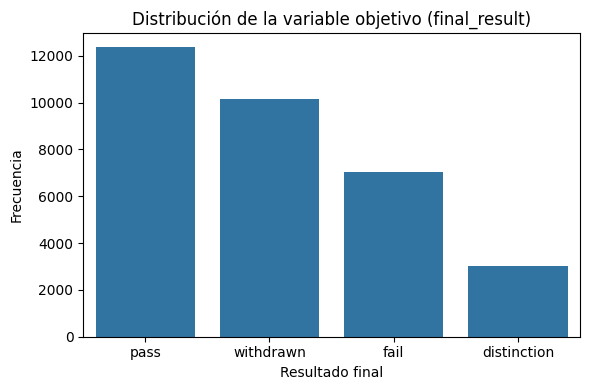

In [ ]:
# GRÁFICO 10 — Gráfico libre adicional
# Elige el tipo que mejor responde una pregunta adicional de tu equipo.
# Opciones: kdeplot, violinplot, regplot, countplot, pairplot (parcial).

# ── FLUJO ─────────────────────────────────────────────────────────────────────────
# G10 — elección libre: este gráfico debe responder una pregunta DISTINTA a G7-G9
# PREGUNTA: ¿Cómo se distribuyen las categorías de la variable objetivo (final_result) y existe evidencia de desbalance entre sus clases?
#   Revisa tus tres gráficos anteriores:
#     ¿Hay una dimensión que no hayas explorado aún?
#     ¿Distribución? ¿Comparación entre grupos? ¿Relación entre dos variables?
#   Elige el tipo que cubra ese ángulo faltante (ver árbol en G7)
#   Verifica antes de codificar:
#     La pregunta de G10 no es una variación menor de G7, G8 o G9
#     El gráfico usa al menos una variable diferente a las de los anteriores
# ── FIN FLUJO ─────────────────────────────────────────────────────────────────────────

# TU CÓDIGO AQUÍ
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
sns.countplot(
    data=df,
    x='final_result',
    order=df['final_result'].value_counts().index,
    ax=axes
)
axes.set_title('Distribución de la variable objetivo (final_result)')
axes.set_xlabel('Resultado final')
axes.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**[EQUIPO — completar] Interpretación del Gráfico 10:**
- ¿Qué pregunta adicional responde este gráfico?
La pregunta es:  ¿Cómo se distribuyen las categorías de la variable objetivo (final_result) y existe evidencia de desbalance entre sus clases?

- ¿Qué nuevo hallazgo aporta respecto a G7–G9?
El gráfico de frecuencias muestra que la variable objetivo (final_result) no presenta una distribución uniforme entre sus categorías. La categoría pass concentra la mayor cantidad de registros, con aproximadamente 12 000 estudiantes, seguida por withdrawn con cerca de 10 000, fail con alrededor de 7 000 y distinction con aproximadamente 3 000 estudiantes.

En consecuencia, se observa un predominio de la categoría pass, mientras que distinction representa la menor proporción de registros. Esto evidencia la existencia de un desbalance entre las clases de la variable objetivo, aspecto que debe considerarse en la etapa de construcción del modelo predictivo, ya que una distribución desigual puede favorecer el aprendizaje de las clases mayoritarias y afectar el desempeño del modelo sobre las clases minoritarias.

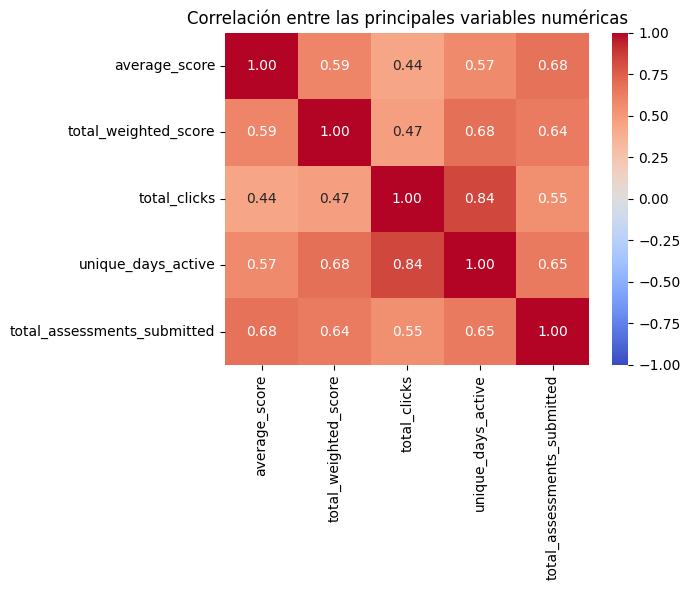

In [ ]:
# ── GRÁFICO 11 (OBLIGATORIO): Heatmap de correlación ────────────────────────
# Selecciona 4-6 variables numéricas relevantes de tu dataset.
# PREGUNTA: ¿Qué relaciones existen entre las principales variables numéricas asociadas al desempeño académico y la interacción de los estudiantes?

# ── FLUJO ─────────────────────────────────────────────────────────────────────────
# G11 — mapa de calor de correlación (obligatorio para todos los equipos)
#   Paso 1 — selección de columnas:
#     Incluye SOLO columnas numéricas (enteros o decimales)
#     Excluye columnas de texto, fechas o identificadores
#   Paso 2 — lectura del mapa:
#     Celda diagonal → siempre vale 1.00 (variable consigo misma)
#     Valor cercano a +1 → relación directa fuerte
#     Valor cercano a -1 → relación inversa fuerte
#     Valor cercano a  0 → sin relación lineal aparente
#   Verifica: ¿hay al menos un par con |correlación| > 0.5?
#             Si no hay ninguno → menciona ese hallazgo en la observación
# ── FIN FLUJO ─────────────────────────────────────────────────────────────────────────

# TU CÓDIGO AQUÍ
# Seleccionar las principales variables numéricas
columnas_numericas = [
    'average_score',
    'total_weighted_score',
    'total_clicks',
    'unique_days_active',
    'total_assessments_submitted'
]

# Calcular la matriz de correlación
correlacion = df[columnas_numericas].corr()

# Crear el heatmap
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax
)

ax.set_title('Correlación entre las principales variables numéricas')

plt.tight_layout()
plt.show()

**[EQUIPO — completar] Interpretación del heatmap (obligatoria):**

(a) Par de mayor correlación positiva
El par de variables que presenta la mayor correlación positiva es total_clicks y unique_days_active, con un coeficiente de 0.84, lo que indica una relación positiva fuerte. Esto sugiere que los estudiantes que registran una mayor cantidad de clics en la plataforma también tienden a permanecer activos durante un mayor número de días

(b) par de mayor correlación negativa o ausencia de correlación
l gráfico no evidencia correlaciones negativas entre las variables analizadas. La menor correlación observada corresponde al par average_score y total_clicks, con un coeficiente de 0.44, lo que representa una correlación positiva moderada.

(c) implicación para el modelado en U4.
Para la construcción del modelo predictivo es recomendable que las variables predictoras no presenten una alta redundancia de información. El heatmap muestra que la mayoría de las variables presentan correlaciones moderadas, mientras que el par total_clicks y unique_days_active alcanza una correlación de 0.84, considerada alta. Este resultado sugiere que ambas variables podrían aportar información similar al modelo y, en la etapa de preprocesamiento, sería conveniente evaluar si es necesario conservar ambas o seleccionar la que ofrezca mayor capacidad predictiva

**Síntesis de hallazgos clave de tu dataset:**

1.- Grafico Boxplot: Las variables average_score y total_weighted_score presentan la mayor capacidad para diferenciar el resultado final, siendo los principales indicadores del desempeño académico.

2.- Grafico Countplot: El nivel educativo previo y la edad muestran los patrones más diferenciados respecto al resultado final, mientras que género, región, nivel socioeconómico y discapacidad presentan distribuciones similares.

3.- Grafico Lineplot + Histplot: Los estudiantes con Distinction presentan mayor rendimiento e interacción en la plataforma, mientras que los grupos Fail y Withdrawn muestran bajos niveles de actividad y participación.

4.- Grafico Countplot: La variable objetivo final_result presenta un desbalance de clases, con predominio de Pass y menor representación de Distinction, aspecto relevante para el entrenamiento del modelo predictivo.

5.- Grafico Heatmap: Las variables total_clicks y unique_days_active presentan una alta correlación (r = 0.84), lo que sugiere posible redundancia de información que deberá evaluarse en la etapa de modelado.



## Cierre y Entrega

**[EQUIPO — completar] Reflexión analítica:**
En prosa continua, el equipo describe qué relaciones entre variables confirmaron,
matizaron o refutaron las hipótesis formuladas antes de la sesión;
qué representación visual resultó más informativa para el problema de decisión
del equipo y por qué; y qué preguntas permanecen abiertas para el análisis
exploratorio sistemático de S10.

El análisis exploratorio confirmó que las variables de desempeño académico e interacción en la plataforma están relacionadas con la variable objetivo final_result. Las variables average_score y total_weighted_score fueron las que mejor diferenciaron las categorías de final_result, mientras que el boxplot resultó ser la representación visual más informativa al evidenciar estas diferencias de forma clara. Además, el heatmap mostró una alta correlación entre total_clicks y unique_days_active, lo que sugiere evaluar una posible redundancia entre ambas variables. Finalmente, quedan abiertas preguntas sobre la importancia de cada variable para predecir final_result y el efecto del desbalance de clases en el desempeño del modelo, aspectos que serán abordados en la siguiente etapa del proyecto.
---

**Trabajo autónomo posterior a la sesión:**
Completen los gráficos G7 a G11 con sus respectivas interpretaciones escritas,
síntesis de cinco hallazgos visuales, entregar
antes del sábado 11/07/2026 a las 19:00 — plazo del Producto U3.


Guarden el notebook con el nombre **S09\_[NombreEquipo]\_Seaborn.ipynb**
— este archivo constituye el **Insumo 2 del Panel Analítico de la Unidad 3**
y se integra en la sesión S10.
